In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

from sklearn.metrics import (
    classification_report, 
    accuracy_score, 
    f1_score,
    confusion_matrix
)

In [2]:
df = pd.read_csv("aggregated_rgb_nvi.csv")
df.head()

,Unnamed: 0,geo,B2_mean,B2_stdDev,B3_mean,B3_stdDev,B4_mean,B4_stdDev,B8_mean,B8_stdDev,NDVI_mean,NDVI_stdDev,biome_type,biome_text,biome_group
0,0,"{'type': 'Polygon', 'coordinates': [[[-172.803...",8014.752110,1153.836602,7768.292519,1240.263252,8037.369988,1229.534045,7599.234947,1078.179926,0.002221,0.010976,31,low and high shrub tundra,tundra
1,1,"{'type': 'Polygon', 'coordinates': [[[-173.106...",7976.777540,841.268898,7209.138780,958.706724,7581.334883,1081.947973,7462.316863,914.801513,0.012072,0.014536,31,low and high shrub tundra,tundra
2,2,"{'type': 'Polygon', 'coordinates': [[[-155.030...",8388.670007,396.429616,7861.138810,396.773853,8051.339552,474.017990,7825.406582,445.930815,-0.003776,0.012557,31,low and high shrub tundra,tundra
3,3,"{'type': 'Polygon', 'coordinates': [[[-152.811...",3335.358878,1588.089320,3189.273628,1453.074635,3202.677773,1462.753105,3862.360300,1033.792733,0.169454,0.116453,15,cold evergreen needleleaf forest,forest
4,4,"{'type': 'Polygon', 'coordinates': [[[-153.836...",8469.225552,2017.029856,8447.530301,2100.653780,8500.561617,2153.822305,7955.037899,2058.134153,-0.023936,0.017433,31,low and high shrub tundra,tundra


In [3]:
df["biome_type"].value_counts()

biome_type
22    1084
15     545
1      511
18     501
4      400
20     286
9      268
27     243
13     225
3      169
17     113
31     112
14     107
2       91
16      65
28      61
7       50
30      45
8       23
Name: count, dtype: int64

In [4]:
biome_mapping = {1:"tropical evergreen broadleaf forest",
                 2:"tropical semi-evergreen broadleaf forest",
                 3:"tropical deciduous broadleaf forest and woodland",
                 4:"warm-temperate evergreen broadleaf and mixed forest",
                 7:"cool-temperate rainforest",
                 8:"cool evergreen needleleaf forest",
                 9:"cool mixed forest",
                 13:"temperate deciduous broadleaf forest",
                 14:"cold deciduous forest",
                 15:"cold evergreen needleleaf forest",
                 16:"temperate sclerophyll woodland and shrubland",
                 17:"temperate evergreen needleleaf open woodland",
                 18:"tropical savanna",
                 20:"xerophytic woods/scrub",
                 22:"steppe",
                 27:"desert",
                 28:"graminoid and forb tundra",
                 30:"erect dwarf shrub tundra",
                 31:"low and high shrub tundra",
                 32:"prostrate dwarf shrub tundra",    
}
#y_test_int = y_test.replace({value: key for key, value in biome_mapping.items()})
#y_test_int

In [5]:
y_indiv = df["biome_type"]
y = df["biome_group"]
X = df.drop(columns=["biome_type", "biome_text", "biome_group", "Unnamed: 0"], errors="ignore")

X = X.select_dtypes(include=["number"])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_test, y_train_indiv, y_test_indiv = train_test_split(
    X,
    y_indiv,
    test_size=0.2,
    random_state=42,
    stratify=y
)

              precision    recall  f1-score   support

           1       0.76      0.81      0.79       104
           2       0.30      0.18      0.22        17
           3       0.62      0.38      0.48        39
           4       0.46      0.49      0.47        78
           7       0.71      1.00      0.83         5
           8       0.00      0.00      0.00         3
           9       0.39      0.34      0.36        50
          13       0.39      0.23      0.29        53
          14       0.55      0.44      0.49        27
          15       0.54      0.58      0.56       109
          16       0.67      0.20      0.31        10
          17       0.00      0.00      0.00        25
          18       0.55      0.63      0.58        94
          20       0.38      0.26      0.31        43
          22       0.56      0.82      0.67       226
          27       0.57      0.30      0.39        54
          28       0.29      0.18      0.22        11
          30       0.38    

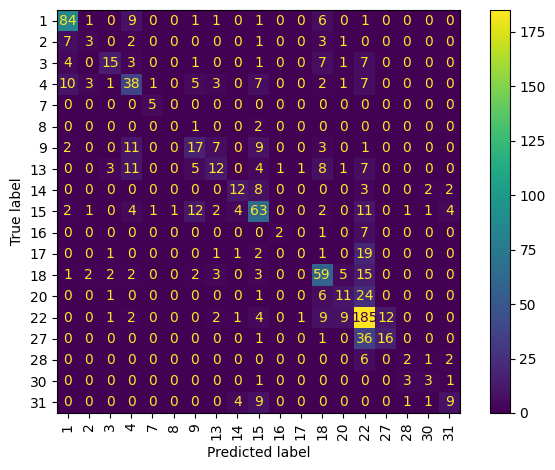

In [7]:
# supervised
clf_indiv = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

clf_indiv.fit(X_train, y_train_indiv)

y_pred_indiv = clf_indiv.predict(X_test)
print(classification_report(y_test_indiv, y_pred_indiv))

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_estimator(
    clf_indiv, X_test, y_test_indiv, xticks_rotation="vertical"
)
plt.tight_layout()
plt.show()

In [8]:
labels = [22, 27]
cm = confusion_matrix(y_test_indiv, y_pred_indiv, labels=labels)
cm

array([[185,  12],
       [ 36,  16]])

In [9]:
X_test_with_labels = X_test.copy()

X_test_with_labels['geo'] = df['geo']
X_test_with_labels['true_label'] = y_test_indiv
X_test_with_labels['predicted_label'] = y_pred_indiv

mask_27_as_22 = (y_test_indiv == 27) & (y_pred_indiv == 22)
X_27_as_22 = X_test_with_labels[mask_27_as_22]

mask_27_correct = (y_test_indiv == 27) & (y_pred_indiv == 27)
X_27_correct = X_test_with_labels[mask_27_correct]

mask_22_correct = (y_test_indiv == 22) & (y_pred_indiv == 22)
X_22 = X_test_with_labels[mask_22_correct]
#X_22 = X_test_with_labels[y_test_indiv == 22]

#X_test_with_labels[(X_test_with_labels['true_label'] == 22) & (X_test_with_labels['predicted_label'] == 27)]['g

In [17]:
X_test_with_labels[(y_test_indiv == 7) & (y_pred_indiv == 7)]["geo"].iloc[1]

"{'type': 'Polygon', 'coordinates': [[[-68.74491750643173, -53.86364711292221], [-68.72975945669774, -53.86364711292221], [-68.72975945669774, -53.854649976253306], [-68.74491750643173, -53.854649976253306], [-68.74491750643173, -53.86364711292221]]]}"

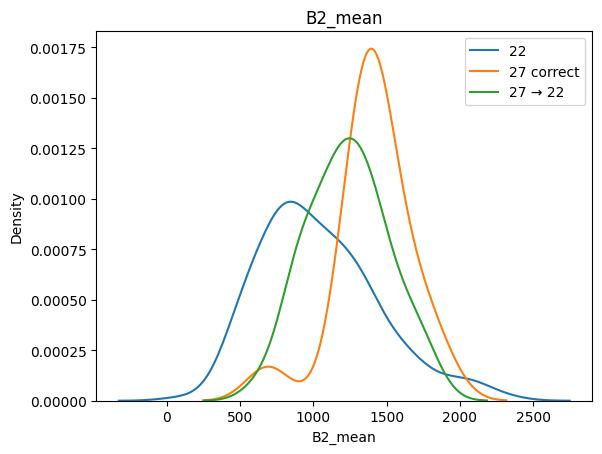

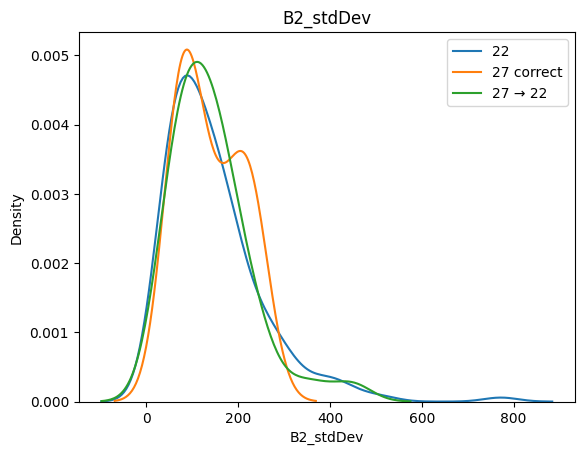

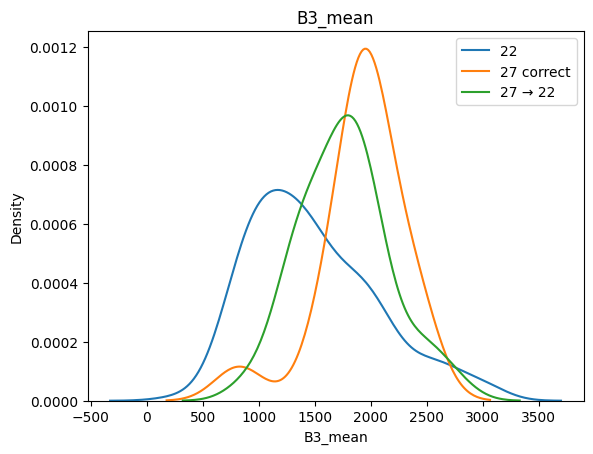

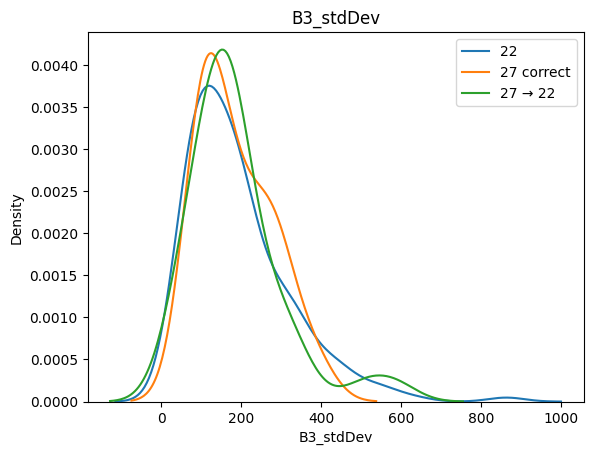

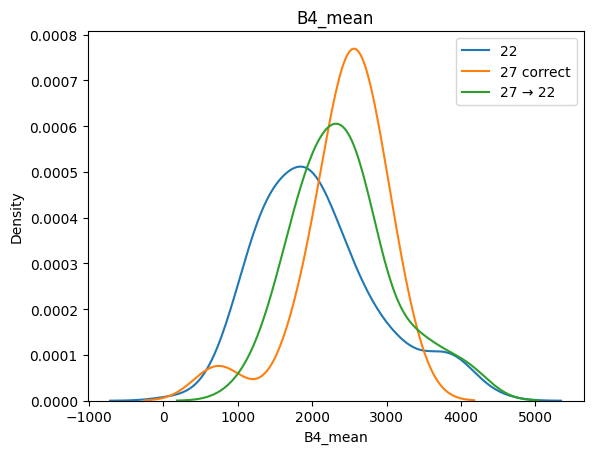

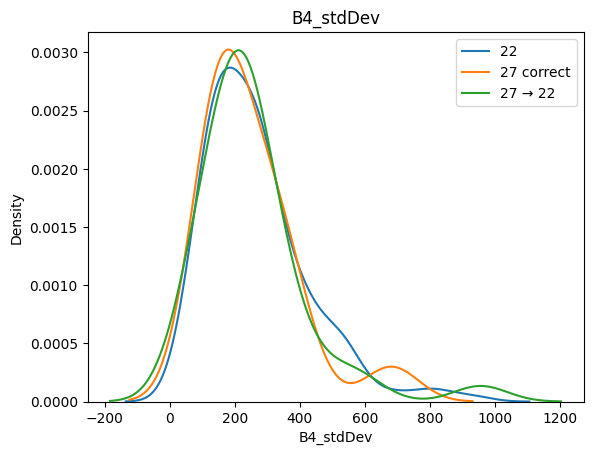

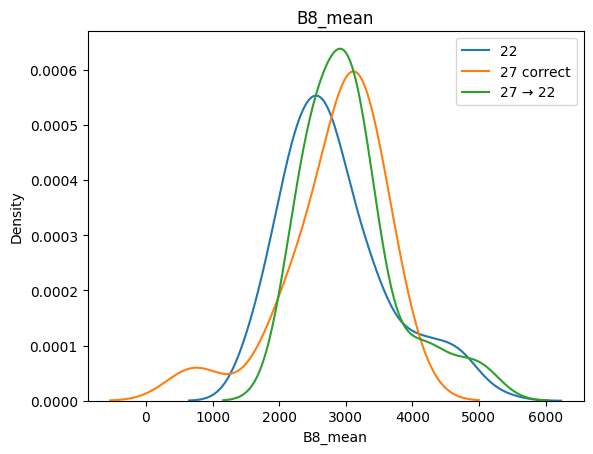

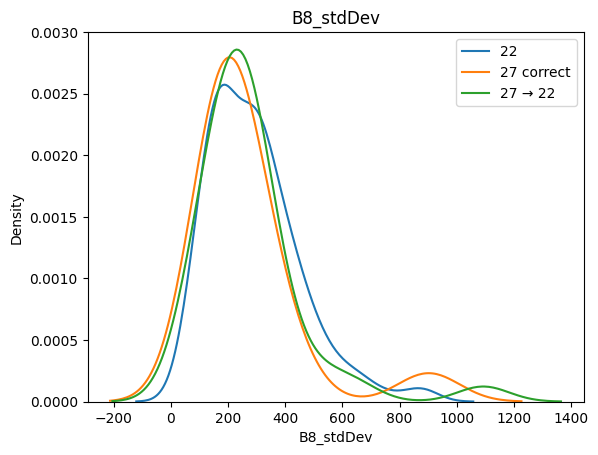

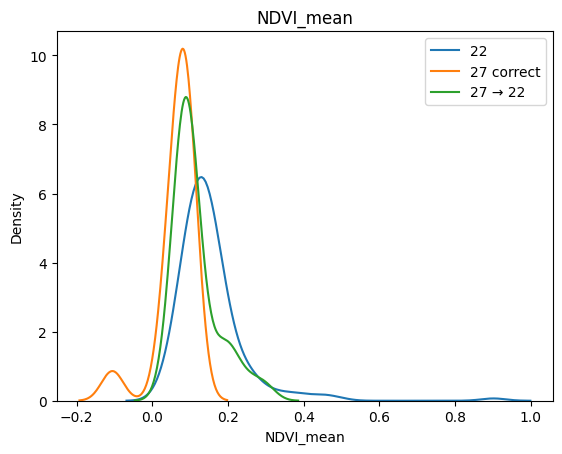

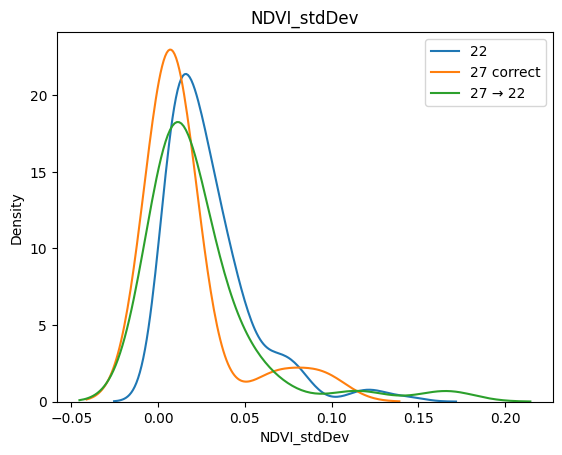

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_features = ["B2_mean",	"B2_stdDev",	"B3_mean",	"B3_stdDev",	"B4_mean",	"B4_stdDev",	"B8_mean",	"B8_stdDev",	"NDVI_mean","NDVI_stdDev"]
for col in numeric_features:
    sns.kdeplot(X_22[col], label='22')
    sns.kdeplot(X_27_correct[col], label='27 correct')
    sns.kdeplot(X_27_as_22[col], label='27 → 22')
    plt.title(col)
    plt.legend()
    plt.show()


In [11]:
importances = clf_indiv.feature_importances_
sorted(zip(['B2_mean', 'B2_stdDev', 'B3_mean', 'B3_stdDev', 'B4_mean', 'B4_stdDev',
       'B8_mean', 'B8_stdDev', 'NDVI_mean', 'NDVI_stdDev'], importances), key=lambda x: x[1], reverse=True)


[('NDVI_mean', np.float64(0.13012518547422033)),
 ('B2_mean', np.float64(0.12130743283158138)),
 ('B4_mean', np.float64(0.10757277093910246)),
 ('B3_mean', np.float64(0.10308159738024765)),
 ('NDVI_stdDev', np.float64(0.09644009014095292)),
 ('B8_mean', np.float64(0.0945173078312384)),
 ('B8_stdDev', np.float64(0.09365221152397953)),
 ('B2_stdDev', np.float64(0.09059623112073807)),
 ('B4_stdDev', np.float64(0.08172104690419865)),
 ('B3_stdDev', np.float64(0.08098612585374076))]

In [12]:
import shap 
shap.initjs()

In [13]:
explainer = shap.TreeExplainer(clf_indiv)

In [14]:
explainer

In [15]:
shap_values = explainer.shap_values(X_test)

In [16]:
idx = np.where(mask_27_as_22)[0][0]  # one example

shap.force_plot(
    explainer.expected_value[14],
    shap_values[idx][:, 14],
    X_test.iloc[idx]
)


In [17]:
idx2 = np.where(mask_27_correct)[0][0]

shap.force_plot(
    explainer.expected_value[15],
    shap_values[idx2][:, 15],
    X.iloc[idx2]
)


In [18]:
idx3 = np.where(mask_22_correct)[0][-1]

shap.force_plot(
    explainer.expected_value[14],
    shap_values[idx3][:, 14],
    X.iloc[idx3]
)


In [19]:
X_test_with_labels = X_test.copy()

X_test_with_labels['geo'] = df['geo']
X_test_with_labels['true_label'] = y_test_indiv
X_test_with_labels['predicted_label'] = y_pred_indiv

# Filter the DataFrame to show only the rows where the labels do not match
misclassified_rows = X_test_with_labels[X_test_with_labels['true_label'] == 27]
misclassified_rows = misclassified_rows[misclassified_rows['predicted_label'] == 22]
#misclassified_rows

In [20]:
X_test_with_labels.to_csv("classifier_results")

In [21]:
from robust_classify import robust_classify_def

y_indiv_arid = df[(df["biome_type"] == 27) | (df["biome_type"] == 22)]["biome_type"]
X_arid = df[(df["biome_type"] == 27) | (df["biome_type"] == 22)].drop(columns=["biome_type", "biome_text", "biome_group", "geo"], errors="ignore")

robust_classify_def(X_arid, y_indiv_arid)


Training Random Forest classifier...

Making predictions...

Season Classification Report:

              precision    recall  f1-score   support

          22       0.87      0.96      0.91       217
          27       0.69      0.37      0.48        49

    accuracy                           0.85       266
   macro avg       0.78      0.67      0.70       266
weighted avg       0.84      0.85      0.83       266


Training SVM classifier...

Making predictions...

Season Classification Report:

              precision    recall  f1-score   support

          22       0.85      0.97      0.91       217
          27       0.65      0.22      0.33        49

    accuracy                           0.83       266
   macro avg       0.75      0.60      0.62       266
weighted avg       0.81      0.83      0.80       266


Training Naives Bayes classifier...

Making predictions...

Season Classification Report:

              precision    recall  f1-score   support

          22       0.88

In [22]:
df

,Unnamed: 0,geo,B2_mean,B2_stdDev,B3_mean,B3_stdDev,B4_mean,B4_stdDev,B8_mean,B8_stdDev,NDVI_mean,NDVI_stdDev,biome_type,biome_text,biome_group
0,0,"{'type': 'Polygon', 'coordinates': [[[-172.803...",8014.752110,1153.836602,7768.292519,1240.263252,8037.369988,1229.534045,7599.234947,1078.179926,0.002221,0.010976,31,low and high shrub tundra,tundra
1,1,"{'type': 'Polygon', 'coordinates': [[[-173.106...",7976.777540,841.268898,7209.138780,958.706724,7581.334883,1081.947973,7462.316863,914.801513,0.012072,0.014536,31,low and high shrub tundra,tundra
2,2,"{'type': 'Polygon', 'coordinates': [[[-155.030...",8388.670007,396.429616,7861.138810,396.773853,8051.339552,474.017990,7825.406582,445.930815,-0.003776,0.012557,31,low and high shrub tundra,tundra
3,3,"{'type': 'Polygon', 'coordinates': [[[-152.811...",3335.358878,1588.089320,3189.273628,1453.074635,3202.677773,1462.753105,3862.360300,1033.792733,0.169454,0.116453,15,cold evergreen needleleaf forest,forest
4,4,"{'type': 'Polygon', 'coordinates': [[[-153.836...",8469.225552,2017.029856,8447.530301,2100.653780,8500.561617,2153.822305,7955.037899,2058.134153,-0.023936,0.017433,31,low and high shrub tundra,tundra
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4894,4895,"{'type': 'Polygon', 'coordinates': [[[169.0146...",7554.361092,1019.181541,7015.989461,1147.117079,7310.410051,1343.826932,7337.665426,1250.511737,0.023880,0.012408,31,low and high shrub tundra,tundra
4895,4896,"{'type': 'Polygon', 'coordinates': [[[161.5857...",7443.743503,848.703175,6996.456489,860.169822,7300.029764,943.114016,7221.985060,872.851885,0.007749,0.004582,31,low and high shrub tundra,tundra
4896,4897,"{'type': 'Polygon', 'coordinates': [[[159.5484...",5159.484497,1474.850608,4241.384362,1571.727528,3945.132902,1866.967969,4540.041682,1657.165515,0.054639,0.033973,15,cold evergreen needleleaf forest,forest
4897,4898,"{'type': 'Polygon', 'coordinates': [[[150.7577...",528.247170,166.958312,800.748150,190.715913,1052.189743,258.139178,2452.270266,269.721500,0.356562,0.105916,16,temperate sclerophyll woodland and shrubland,temperate


In [23]:
from robust_classify import robust_classify_def

y_indiv_arid = df[(df["biome_type"] == 27) | (df["biome_type"] == 22)]["biome_type"]
X_arid = df[(df["biome_type"] == 27) | (df["biome_type"] == 22)].drop(columns=["biome_type", "biome_text", "biome_group", "geo", "Unnamed: 0"], errors="ignore")

robust_classify_def(X_arid, y_indiv_arid)


Training Random Forest classifier...

Making predictions...

Season Classification Report:

              precision    recall  f1-score   support

          22       0.86      0.94      0.89       217
          27       0.52      0.31      0.38        49

    accuracy                           0.82       266
   macro avg       0.69      0.62      0.64       266
weighted avg       0.79      0.82      0.80       266


Training SVM classifier...

Making predictions...

Season Classification Report:

              precision    recall  f1-score   support

          22       0.82      1.00      0.90       217
          27       0.00      0.00      0.00        49

    accuracy                           0.82       266
   macro avg       0.41      0.50      0.45       266
weighted avg       0.67      0.82      0.73       266


Training Naives Bayes classifier...

Making predictions...

Season Classification Report:

              precision    recall  f1-score   support

          22       0.89

C:\Users\zizzi\gee\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\zizzi\gee\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\zizzi\gee\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Making predictions...

Season Classification Report:

              precision    recall  f1-score   support

          22       0.85      0.94      0.90       217
          27       0.54      0.29      0.37        49

    accuracy                           0.82       266
   macro avg       0.70      0.62      0.64       266
weighted avg       0.80      0.82      0.80       266

   Classifier  Accuracy  F1 Score
       LDA RF  0.823308  0.800662
Random Forest  0.819549  0.800389
          SVM  0.815789  0.733028
          KNN  0.804511  0.786411
  Naive Bayes  0.744361  0.763950


              precision    recall  f1-score   support

          22       0.86      0.94      0.90       217
          27       0.56      0.31      0.39        49

    accuracy                           0.83       266
   macro avg       0.71      0.63      0.65       266
weighted avg       0.80      0.83      0.81       266



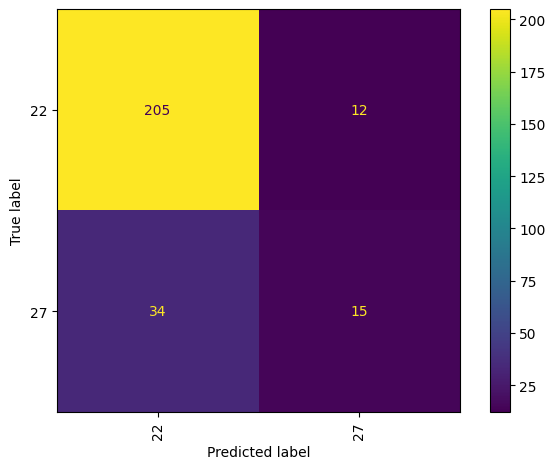

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_arid,
    y_indiv_arid,
    test_size=0.2,
    random_state=42,
    stratify=y_indiv_arid
)

# supervised
clf_indiv_ = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

clf_indiv_.fit(X_train, y_train)

y_pred = clf_indiv_.predict(X_test)
print(classification_report(y_test, y_pred))

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_estimator(
    clf_indiv_, X_test, y_test, xticks_rotation="vertical"
)
plt.tight_layout()
plt.show()

In [25]:
rf_no_ndvi = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_no_ndvi.fit(X_train.drop(columns=['B8_stdDev']), y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

              precision    recall  f1-score   support

          22       0.86      0.94      0.90       217
          27       0.55      0.33      0.41        49

    accuracy                           0.83       266
   macro avg       0.71      0.63      0.65       266
weighted avg       0.80      0.83      0.81       266



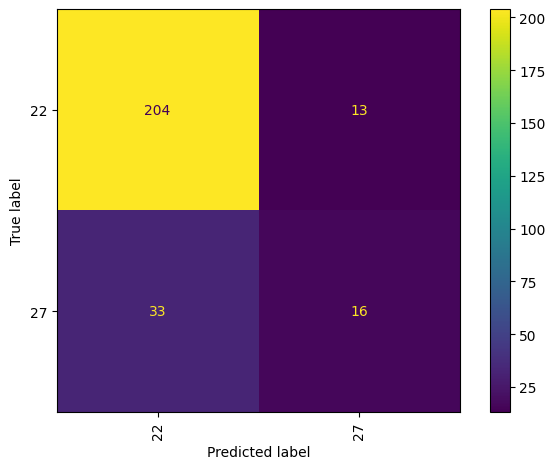

In [26]:
y_pred = rf_no_ndvi.predict(X_test.drop(columns=['B8_stdDev']))
print(classification_report(y_test, y_pred))

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_estimator(
    rf_no_ndvi, X_test.drop(columns=['B8_stdDev']), y_test, xticks_rotation="vertical"
)
plt.tight_layout()
plt.show()

In [27]:
explainer = shap.TreeExplainer(clf_indiv_)

In [28]:
shap_values = explainer.shap_values(X_test)

In [29]:
X_test.iloc[0]

B2_mean         862.613712
B2_stdDev       257.456521
B3_mean        1199.673679
B3_stdDev       318.019715
B4_mean        1575.017127
B4_stdDev       421.492144
B8_mean        2199.583074
B8_stdDev       426.355953
NDVI_mean         0.174903
NDVI_stdDev       0.031466
Name: 1398, dtype: float64

In [30]:
X_test_with_labels = X_test.copy()

X_test_with_labels['geo'] = df['geo']
X_test_with_labels['true_label'] = y_test
X_test_with_labels['predicted_label'] = y_pred

mask_27_as_22 = (y_test == 27) & (y_pred == 22)
X_27_as_22 = X_test_with_labels[mask_27_as_22]

mask_27_correct = (y_test == 27) & (y_pred == 27)
X_27_correct = X_test_with_labels[mask_27_correct]

mask_22_correct = (y_test == 22) & (y_pred == 22)
X_22_correct = X_test_with_labels[mask_22_correct]
#X_22 = X_test_with_labels[y_test_indiv == 22]

#X_test_with_labels[(X_test_with_labels['true_label'] == 22) & (X_test_with_labels['predicted_label'] == 27)]['g

In [31]:
idx = np.where(mask_27_as_22)[0][4]  # one example

shap.force_plot(
    explainer.expected_value[1],
    shap_values[idx][:, 1],
    X_test.iloc[idx]
)

In [32]:
idx3 = np.where(mask_27_correct)[0][3]

shap.force_plot(
    explainer.expected_value[0],
    shap_values[idx3][:, 0],
    X_test.iloc[idx3]
)

In [33]:
idx2 = np.where(mask_22_correct)[0][8]

shap.force_plot(
    explainer.expected_value[0],
    shap_values[idx2][:, 0],
    X_test.iloc[idx2]
)

In [34]:
shap_values[:, :, 0].shape

(266, 10)

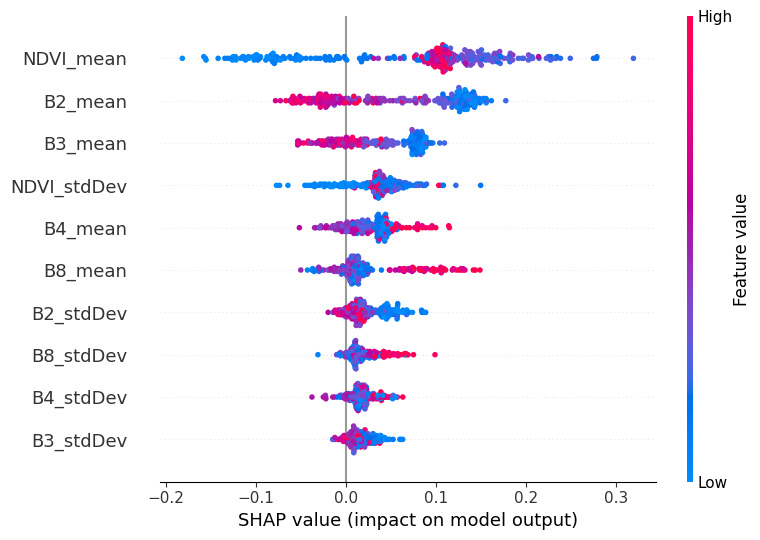

In [35]:
shap.summary_plot(shap_values[:, :, 0], X_test)

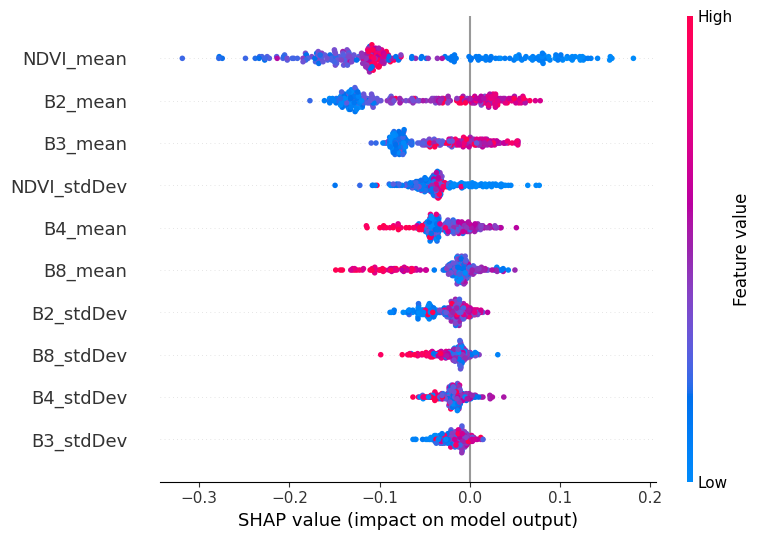

In [36]:
shap.summary_plot(shap_values[:, :, 1], X_test)